Importación de librerías y montaje de Google Drive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Carga y lectura de la base de datos

In [2]:
# 1. Cargar el dataset con la codificación adecuada
ruta = "/content/drive/MyDrive/semestre 6/sist int/Mobiles Dataset (2025).csv"
df = pd.read_csv(ruta, encoding="latin1")

# Reemplazar la coma por punto si va seguida de exactamente 2 dígitos al final (como 396,22)
df["Launched Price (USA)"] = df["Launched Price (USA)"].astype(str)
df["Launched Price (USA)"] = df["Launched Price (USA)"].str.replace(
    r",(\d{2})$", r".\1", regex=True
)

# --------------------------------------------------
# Limpieza de Precios (USD, PKR, INR, CNY, AED)
# --------------------------------------------------
columnas_precios = [
    "Launched Price (Pakistan)",
    "Launched Price (India)",
    "Launched Price (China)",
    "Launched Price (USA)",
    "Launched Price (Dubai)",
]

for col in columnas_precios:
    # 1. Quitar comas de separadores de miles ("224,999" -> "224999")
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    # 2. Extraer el primer patrón numérico (entero o decimal) y convertir a float
    df[col] = pd.to_numeric(
        df[col].str.extract(r"(\d+\.?\d*)")[0], errors="coerce"
    )

# --------------------------------------------------
# Limpieza de Especificaciones Técnicas (RAM, Peso, Batería, etc.)
# --------------------------------------------------
# Para Batería (quitar comas de miles antes de extraer)
df["Battery Capacity"] = df["Battery Capacity"].astype(str).str.replace(
    ",", "", regex=False
)

# Extraer el valor numérico en cada columna técnica
columnas_tecnicas = [
    "Mobile Weight",
    "RAM",
    "Front Camera",
    "Back Camera",
    "Battery Capacity",
    "Screen Size",
]

for col in columnas_tecnicas:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.extract(r"(\d+\.?\d*)")[0], errors="coerce"
    )

# Verificar tipos de datos resultantes
print(df.dtypes)
print("--- PRIMEROS REGISTROS ---")
print(df.head())

print("\n--- NOMBRES DE LAS COLUMNAS ---")
print(df.columns.tolist())

print("\n--- TAMAÑO DE LA BASE DE DATOS ---")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Company Name                  object
Model Name                    object
Mobile Weight                float64
RAM                          float64
Front Camera                 float64
Back Camera                  float64
Processor                     object
Battery Capacity               int64
Screen Size                  float64
Launched Price (Pakistan)    float64
Launched Price (India)         int64
Launched Price (China)         int64
Launched Price (USA)         float64
Launched Price (Dubai)         int64
Launched Year                  int64
dtype: object
--- PRIMEROS REGISTROS ---
  Company Name            Model Name  Mobile Weight  RAM  Front Camera  \
0        Apple       iPhone 16 128GB          174.0  6.0          12.0   
1        Apple       iPhone 16 256GB          174.0  6.0          12.0   
2        Apple       iPhone 16 512GB          174.0  6.0          12.0   
3        Apple  iPhone 16 Plus 128GB          203.0  6.0          12.0   
4        Apple  iPhone 16 Plus 256

Detección de valores faltantes (nulos)

In [3]:
print("--- CANTIDAD DE VALORES FALTANTES POR COLUMNA ---")
print(df.isna().sum())

print("\n--- PORCENTAJE DE VALORES FALTANTES ---")
porcentaje_faltantes = df.isna().mean() * 100
print(porcentaje_faltantes)

# Visualizar las filas que contienen algún valor nulo
df_nulos = df[df.isna().any(axis=1)]
print(f"\nTotal de filas con al menos un nulo: {len(df_nulos)}")

--- CANTIDAD DE VALORES FALTANTES POR COLUMNA ---
Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    1
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64

--- PORCENTAJE DE VALORES FALTANTES ---
Company Name                 0.000000
Model Name                   0.000000
Mobile Weight                0.000000
RAM                          0.000000
Front Camera                 0.000000
Back Camera                  0.000000
Processor                    0.000000
Battery Capacity             0.000000
Screen Size                  0.000000
Launched Price (Pakistan)    0.107527
Launched Price (India)       0.000000
Launched Pric

Identificación y eliminación de filas duplicadas

In [4]:
print("--- ANÁLISIS DE DUPLICADOS ---")
num_duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicados}")

if num_duplicados > 0:
    print("\nVisualizando duplicados:")
    print(df[df.duplicated(keep=False)])

    # Eliminación de duplicados
    df_sin_duplicados = df.drop_duplicates()
    print(f"\nTamaño original: {df.shape}")
    print(f"Tamaño sin duplicados: {df_sin_duplicados.shape}")
else:
    df_sin_duplicados = df.copy()
    print("No se encontraron filas duplicadas.")

--- ANÁLISIS DE DUPLICADOS ---
Número de filas duplicadas: 15

Visualizando duplicados:
    Company Name        Model Name  Mobile Weight   RAM  Front Camera  \
344         Oppo          A3 128GB          186.0   4.0           5.0   
347         Oppo          A3 128GB          186.0   4.0           5.0   
423         Oppo        K11x 128GB          195.0   8.0          16.0   
424         Oppo        K11x 256GB          195.0  12.0          16.0   
425         Oppo        K10x 128GB          195.0   6.0          16.0   
426         Oppo        K10x 256GB          195.0   8.0          16.0   
427         Oppo      K10 5G 128GB          205.0   8.0          16.0   
428         Oppo         K9x 128GB          194.0   6.0          16.0   
429         Oppo         K9x 256GB          194.0   8.0          16.0   
430         Oppo   K9 Pro 5G 128GB          180.0   8.0          16.0   
431         Oppo   K9 Pro 5G 256GB          180.0  12.0          16.0   
432         Oppo       K9 5G 128GB  

Tratamiento e imputación de valores faltantes

In [5]:
# Creamos una copia de trabajo limpia a partir de la base sin duplicados
df_base = df_sin_duplicados.copy()

# Estrategia de imputación para columnas numéricas (si aplicara)
columnas_numericas = df_base.select_dtypes(include=[np.number]).columns

# Imputación por Mediana en las variables numéricas
df_imputado = df_base.copy()
for col in columnas_numericas:
    if df_imputado[col].isna().sum() > 0:
        mediana_val = df_imputado[col].median()
        df_imputado[col] = df_imputado[col].fillna(mediana_val)
        print(f"Imputado valor nulo en {col} con la mediana: {mediana_val}")

print("\nComprobación de nulos tras imputación:")
print(df_imputado.isna().sum())

# Definimos df_limpio como la base sin faltantes
df_limpio = df_imputado.copy()

Imputado valor nulo en Launched Price (Pakistan) con la mediana: 89999.0

Comprobación de nulos tras imputación:
Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64


Análisis descriptivo y estadísticas de las variables

In [6]:
print("--- RESUMEN ESTADÍSTICO DE LAS CARACTERÍSTICAS NUMÉRICAS ---")
resumen = df_limpio[columnas_numericas].agg(["mean", "std", "min", "median", "max"]).T
resumen.columns = ["Promedio", "Desv. Estándar", "Mínimo", "Mediana", "Máximo"]
print(resumen)

--- RESUMEN ESTADÍSTICO DE LAS CARACTERÍSTICAS NUMÉRICAS ---
                                Promedio  Desv. Estándar   Mínimo   Mediana  \
Mobile Weight                 228.914098      106.164933    135.0    195.00   
RAM                             7.789071        3.191515      1.0      8.00   
Front Camera                   18.166776       12.043474      2.0     16.00   
Back Camera                    46.491585       31.124175      5.0     50.00   
Battery Capacity             5030.280874     1365.571834   2000.0   5000.00   
Screen Size                     7.092678        1.544578      5.0      6.67   
Launched Price (Pakistan)  126519.253552   101980.937494  15999.0  89999.00   
Launched Price (India)      51070.461202    41104.087394   5999.0  35990.00   
Launched Price (China)       3854.038251     2776.052729    499.0   2900.00   
Launched Price (USA)          588.829377      422.151442     79.0    449.00   
Launched Price (Dubai)       2199.737705     1573.019253    299.0   16

Acople con código anterior

In [7]:
# DataFrame con partidas que terminaron únicamente en mate
df_limpio = df

# 1. Definir las condiciones buscando en la columna 'Company Name'
# (Usamos .str.lower() para evitar problemas con mayúsculas/minúsculas)
condiciones = [
    df["Company Name"]
    .str.lower()
    .str.contains("apple|iphone", na=False),  # Apple / iPhone -> 0.75
    df["Company Name"]
    .str.lower()
    .str.contains("samsung", na=False),  # Samsung -> 0.50
]

# 2. Asignar los valores numéricos correspondientes a cada condición
valores = [0.66, 0.33]

# 3. Crear la columna asignando 0.25 como valor por defecto para las demás marcas
df["Marca_Num"] = np.select(condiciones, valores, default=0.25)

# Verificar los resultados
print(df[["Company Name", "Model Name", "Marca_Num"]].head())
print("\nDistribución de la nueva característica:")
print(df["Marca_Num"].value_counts())

  Company Name            Model Name  Marca_Num
0        Apple       iPhone 16 128GB       0.66
1        Apple       iPhone 16 256GB       0.66
2        Apple       iPhone 16 512GB       0.66
3        Apple  iPhone 16 Plus 128GB       0.66
4        Apple  iPhone 16 Plus 256GB       0.66

Distribución de la nueva característica:
Marca_Num
0.25    745
0.66     97
0.33     88
Name: count, dtype: int64


Gráficos de dispersión para observar relaciones con la variable objetivo en el DF de mates

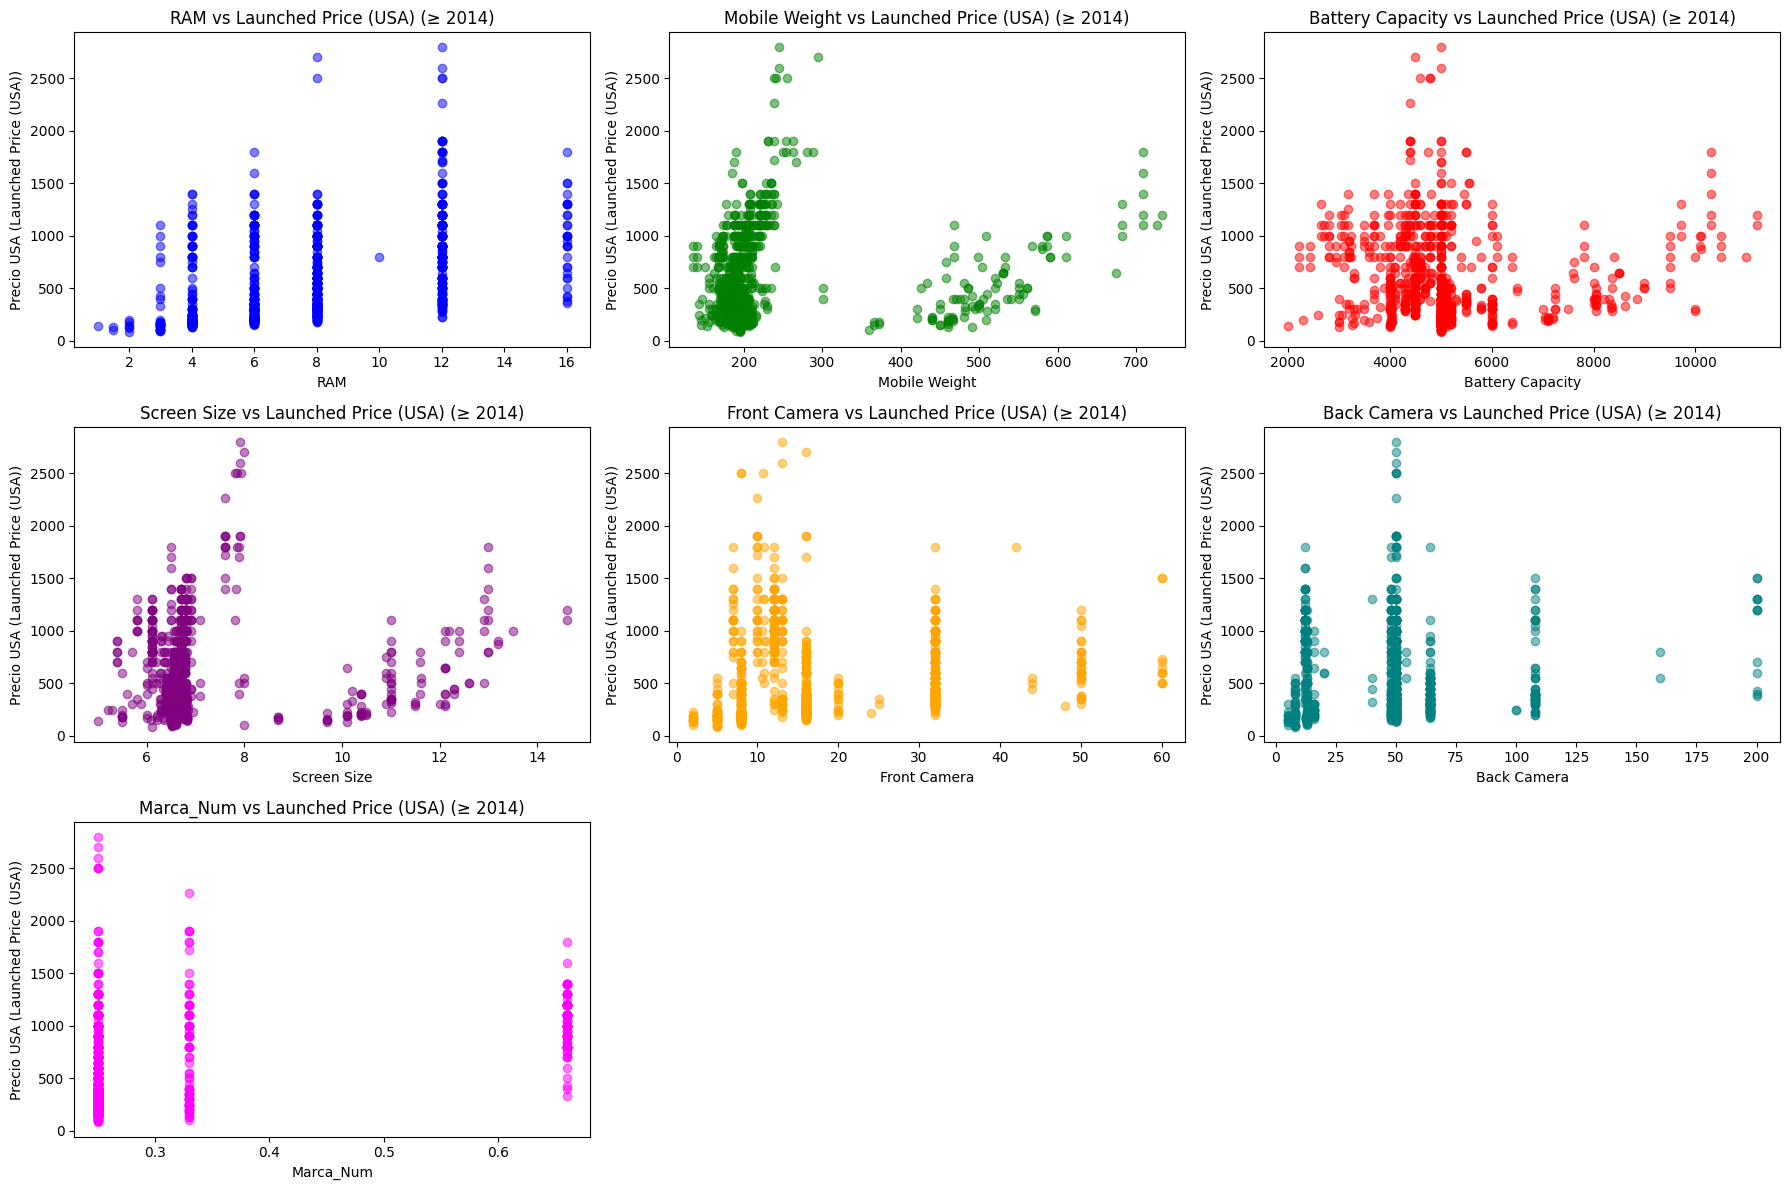

In [8]:
# 2. Definir el año mínimo desde el cual deseas incluir celulares
ano_minimo = 2014

# 3. Filtrar el DataFrame antes de graficar
df_filtrado = df[df["Launched Year"] >= ano_minimo].copy()
# 4. Incluir 'Marca_Num' en la lista de características (ahora son 7)
caracteristicas = [
    "RAM",
    "Mobile Weight",
    "Battery Capacity",
    "Screen Size",
    "Front Camera",
    "Back Camera",
    "Marca_Num",
]
variable_objetivo = "Launched Price (USA)"

# Configurar figura con una cuadrícula de 3 filas por 3 columnas (9 espacios)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Paleta de 7 colores
colores = ["blue", "green", "red", "purple", "orange", "teal", "magenta"]

# Generar gráficos de dispersión usando el DataFrame filtrado
for i, col in enumerate(caracteristicas):
    axes[i].scatter(
        df_filtrado[col],
        df_filtrado[variable_objetivo],
        alpha=0.5,
        color=colores[i],
    )
    axes[i].set_xlabel(f"{col}")
    axes[i].set_ylabel(f"Precio USA ({variable_objetivo})")
    axes[i].set_title(f"{col} vs {variable_objetivo} (≥ {ano_minimo})")

# Ocultar los dos subplots vacíos de la cuadrícula (posiciones 7 y 8)
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.show()

Matriz de correlación (mates)

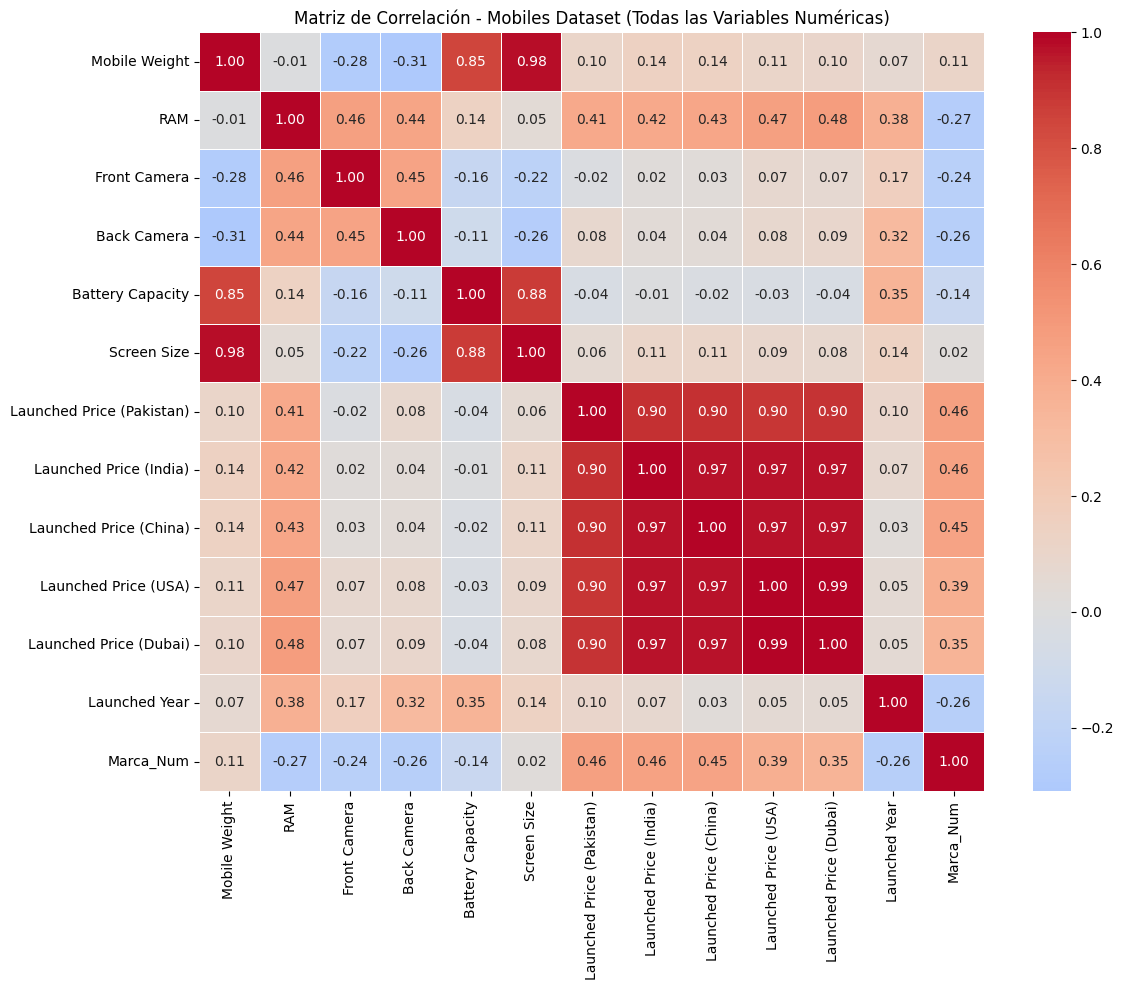


Correlación de todas las características numéricas con 'Launched Price (USA)' (ordenadas de mayor a menor):
Launched Price (USA)         1.000000
Launched Price (Dubai)       0.990397
Launched Price (India)       0.969513
Launched Price (China)       0.967686
Launched Price (Pakistan)    0.897314
RAM                          0.466817
Marca_Num                    0.385923
Mobile Weight                0.109681
Screen Size                  0.089902
Back Camera                  0.080237
Front Camera                 0.072475
Launched Year                0.053495
Battery Capacity            -0.030196
Name: Launched Price (USA), dtype: float64


In [9]:
import seaborn as sns

# Seleccionar todas las columnas numéricas
df_numerico = df_filtrado.select_dtypes(include=["number"])

# Cálculo de la matriz de correlación completa
df_corr_completa = df_numerico.corr()

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_corr_completa,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f",
)
plt.title("Matriz de Correlación - Mobiles Dataset (Todas las Variables Numéricas)")
plt.tight_layout()
plt.show()

# Mostrar la correlación ordenada de todas las variables con 'Launched Price (USA)'
variable_objetivo = "Launched Price (USA)"
print(
    f"\nCorrelación de todas las características numéricas con '{variable_objetivo}' (ordenadas de mayor a menor):"
)
print(df_corr_completa[variable_objetivo].sort_values(ascending=False))

In [10]:

# 1. Definir las 7 características de entrada y la variable objetivo
caracteristicas = [
    "RAM",
    "Mobile Weight",
    "Battery Capacity",
    "Screen Size",
    "Front Camera",
    "Back Camera",
    "Marca_Num",
]
variable_objetivo = "Launched Price (USA)"

# --------------------------------------------------
# Preparación de Matrices (Usando el df_filtrado >= 2023)
# --------------------------------------------------
# Matriz de características X (raw) y vector objetivo y
X_raw = df_filtrado[caracteristicas].values
y = df_filtrado[variable_objetivo].values

# Número de muestras
N = len(X_raw)

# Agregar columna de unos al inicio para el término independiente (intercepto / bias)
X_lineal = np.column_stack([np.ones(N), X_raw])

print("--- DataFrame: Mobile Dataset (Filtrado) ---")
print("Forma de X_raw:", X_raw.shape)
print("Forma de X_lineal (con columna de unos):", X_lineal.shape)
print("Forma del vector objetivo y:", y.shape)

--- DataFrame: Mobile Dataset (Filtrado) ---
Forma de X_raw: (930, 7)
Forma de X_lineal (con columna de unos): (930, 8)
Forma del vector objetivo y: (930,)


División en Train y Test

In [11]:

# Fijar semilla para reproducibilidad
np.random.seed(42)

# --------------------------------------------------
# División Train/Test (80% / 20%) para Mobiles Dataset
# --------------------------------------------------
# Generar índices y desordenar
indices = np.arange(len(X_lineal))
np.random.shuffle(indices)

# Determinar punto de corte (80% entrenamiento)
limite = int(len(X_lineal) * 0.8)
train_idx, test_idx = indices[:limite], indices[limite:]

# Crear conjuntos de entrenamiento y prueba
X_train, y_train = X_lineal[train_idx], y[train_idx]
X_test, y_test = X_lineal[test_idx], y[test_idx]

print("--- Conjunto Mobiles Dataset (Filtrado) ---")
print(f"Train: {len(X_train)} muestras")
print(f"Test:  {len(X_test)} muestras")

--- Conjunto Mobiles Dataset (Filtrado) ---
Train: 744 muestras
Test:  186 muestras


Entrenamiento polinomial a ambos DF

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Definir el transformador polinomial de grado 2
poly4 = PolynomialFeatures(degree=2)

# --------------------------------------------------
# Regresión Polinomial (Grado 2) para Mobiles Dataset
# --------------------------------------------------
# Transformar las características numéricas originales (X_raw) a grado 2
X_poly = poly4.fit_transform(X_raw)

# Utilizar la misma división train/test generada anteriormente
X_train_p = X_poly[train_idx]
X_test_p = X_poly[test_idx]

# Entrenamiento del modelo
model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train)

# Predicciones
y_pred_train = model_poly.predict(X_train_p)
y_pred_test = model_poly.predict(X_test_p)

# Evaluación y visualización de métricas
# Calcular el error medio en dólares (RMSE)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== Mobiles Dataset (Polinomial Grado 2) ===")
print("Forma de X polinomial:", X_poly.shape)
print(
    f"Train R2: {r2_score(y_train, y_pred_train):.4f} | MSE:"
    f" {mean_squared_error(y_train, y_pred_train):.4f} | Error:"
    f" ${rmse_train:.2f} USD"
)
print(
    f"Test  R2: {r2_score(y_test, y_pred_test):.4f} | MSE:"
    f" {mean_squared_error(y_test, y_pred_test):.4f} | Error:"
    f" ${rmse_test:.2f} USD"
)

# --------------------------------------------------
# Construcción e Impresión de la Ecuación General
# --------------------------------------------------
feature_names = getattr(X_raw, "columns", [f"X{i+1}" for i in range(X_raw.shape[1])])
poly_feature_names = poly4.get_feature_names_out(feature_names)

terminos = [f"{model_poly.intercept_:.4f}"]
for coef, name in zip(model_poly.coef_[1:], poly_feature_names[1:]):
    name_formatted = name.replace(" ", " * ")
    signo = "+" if coef >= 0 else "-"
    terminos.append(f"{signo} {abs(coef):.4f} * ({name_formatted})")

ecuacion_general = "y = " + " ".join(terminos)

print("\n--- ECUACIÓN GENERAL DEL MODELO ---")
print(ecuacion_general)

=== Mobiles Dataset (Polinomial Grado 2) ===
Forma de X polinomial: (930, 36)
Train R2: 0.6965 | MSE: 54740.6918 | Error: $233.97 USD
Test  R2: 0.5782 | MSE: 69064.4090 | Error: $262.80 USD

--- ECUACIÓN GENERAL DEL MODELO ---
y = -2164.5696 + 38.2916 * (X1) + 0.3440 * (X2) + 0.7807 * (X3) - 226.3199 * (X4) + 36.4971 * (X5) - 3.9658 * (X6) + 3620.3041 * (X7) - 0.0665 * (X1^2) - 0.0598 * (X1 * X2) - 0.0275 * (X1 * X3) + 35.1342 * (X1 * X4) - 2.3732 * (X1 * X5) - 0.2895 * (X1 * X6) + 45.1571 * (X1 * X7) + 0.0022 * (X2^2) + 0.0030 * (X2 * X3) - 3.3780 * (X2 * X4) + 0.2197 * (X2 * X5) + 0.0390 * (X2 * X6) + 23.0074 * (X2 * X7) + 0.0001 * (X3^2) - 0.3134 * (X3 * X4) + 0.0064 * (X3 * X5) - 0.0009 * (X3 * X6) - 0.7685 * (X3 * X7) + 200.7316 * (X4^2) - 14.4860 * (X4 * X5) - 1.1627 * (X4 * X6) - 535.2232 * (X4 * X7) + 0.3149 * (X5^2) + 0.1309 * (X5 * X6) - 69.1218 * (X5 * X7) + 0.0128 * (X6^2) + 19.5757 * (X6 * X7) - 686.6436 * (X7^2)


Visualización de resultados (Valores Reales vs Predichos)

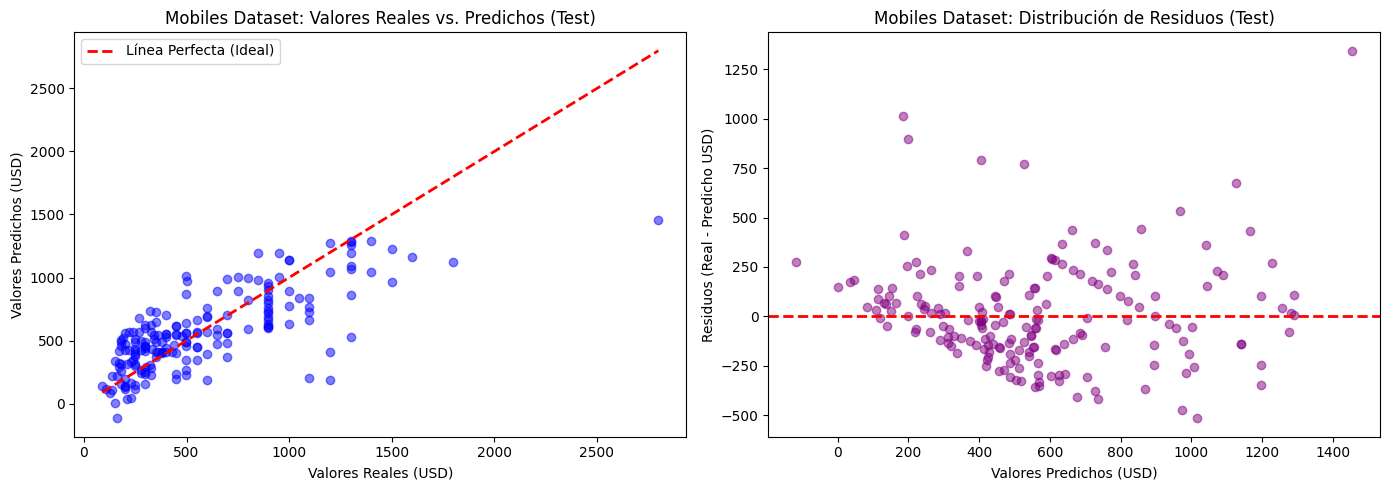

In [13]:

# Calcular residuos para el conjunto de test de celulares
residuos_test = y_test - y_pred_test

# Crear figura con 1 fila y 2 columnas para el análisis del modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------
# 1. Mobiles Dataset: Reales vs Predichos
# --------------------------------------------------
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color="blue")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Línea Perfecta (Ideal)",
)
axes[0].set_xlabel("Valores Reales (USD)")
axes[0].set_ylabel("Valores Predichos (USD)")
axes[0].set_title("Mobiles Dataset: Valores Reales vs. Predichos (Test)")
axes[0].legend()

# --------------------------------------------------
# 2. Mobiles Dataset: Gráfico de Residuos
# --------------------------------------------------
axes[1].scatter(y_pred_test, residuos_test, alpha=0.5, color="purple")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Valores Predichos (USD)")
axes[1].set_ylabel("Residuos (Real - Predicho USD)")
axes[1].set_title("Mobiles Dataset: Distribución de Residuos (Test)")

plt.tight_layout()
plt.show()

Exportar el modelo

In [15]:
import joblib
from google.colab import files

# Exportar el transformador polinomial y el objeto del modelo ajustado
modelo_exportado = {"poly": poly4, "model": model_poly}

joblib.dump(modelo_exportado, "modelo_polinomial.joblib")
files.download("modelo_polinomial.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>